In [ ]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc, ConfusionMatrixDisplay

In [92]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m'
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m'

def colored_text(color, txt):
    return color + str(txt) + RESET

In [93]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [94]:
# converting columns with integers to the correct type
column_names_to_int = ['Num_Acc', 'catr', 'v1', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [95]:
# let's see the proportion of empty values in these sets of tables
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For catr proportion missing: 0.00%
For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For circ proportion missing: 6.00%
For nbv proportion missing: 2.97%
For vosp proportion missing: 2.53%
For prof proportion missing: 0.08%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For plan proportion missing: 0.07%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%
For surf proportion missing: 0.09%
For infra proportion missing: 1.10%
For situ proportion missing: 0.11%
For vma proportion missing: 3.23%


In [96]:
# First we are dropping features that we are not going to use because of their high proportion 
# and of low utility on our target prediction (check the report for more detailed explanation)
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)

In [97]:
# For the remaining missing values, we will split the features into two groups:
# those for which we do not have an obvious or reliable imputation strategy, and for which
# we will simply use the most frequent value within the current category;
# and those for which we can use a more informed imputation based on a correlated feature
# The first group of features is the following:

imputer = SimpleImputer(strategy="most_frequent")

small_na_cols = ['catr', 'circ', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ']
df_lieux[small_na_cols] = df_lieux[small_na_cols].replace({pandas.NA: np.nan})
df_lieux[small_na_cols] = imputer.fit_transform(df_lieux[small_na_cols])

# For the second group, we have ["vma", "nbv"], which we will impute
# using the median value within the categories of the features most related to them,
# namely "catr" for "vma" and "circ" for "nbv"

In [98]:
# let's start our feature analysis with speed limit feature, first we convert it to the correct type
df_lieux["vma"] = pandas.to_numeric(df_lieux["vma"], errors="coerce")

In [99]:
# and then seeing its distribution
df_lieux["vma"].describe()
# we observe very strange min and max values

count    347911.000000
mean         58.864782
std          23.598701
min           0.000000
25%          50.000000
50%          50.000000
75%          80.000000
max         901.000000
Name: vma, dtype: float64

In [100]:
# first we are making a list of valid speed limits and seeing how many rows are outside of these values
valid_limits = [5,10,15,20,30,50,70,80,90,110,130]
percentage = 1 - (len(df_lieux['vma'][df_lieux['vma'].isin(valid_limits)]) / len(df_lieux['vma']))
print(f"Proportion of speed limit outside valid limits: {percentage * 100 :0.2f}%")

Proportion of speed limit outside valid limits: 3.78%


In [101]:
# The proportion is not very high, but we will keep these rows and try
# to impute the incorrect and missing values in this variable
# First, we replace the incorrect values with missing values:
df_lieux['vma'] = df_lieux['vma'].where(df_lieux['vma'].isin(valid_limits), np.nan)

# Then, we impute the missing values using the median speed limit
# for each road category
df_lieux["vma"] = df_lieux.groupby("catr")["vma"].transform(
    lambda x: x.fillna(x.median()) 
)

In [102]:
# now we work on the number of traffic lines (nbv), let's see which values this feature takes
df_lieux["nbv"] = pandas.to_numeric(df_lieux["nbv"], errors="coerce")
nvb_val = df_lieux["nbv"].unique()
nvb_val.sort()
nvb_val

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       nan])

In [103]:
# value 0 is almost surely means missing value, and 
# we checked on the internet and found out that the number of traffic lines higher than 9 is very very rare, 
# so these values are almost surely errors or outliers
# let's check the percentage of both missing and too high values for this feature
percentage_empty = len(df_lieux['nbv'][(df_lieux['nbv'] == 0) | (df_lieux["nbv"].isna())]) / len(df_lieux['nbv'])
print(f"Proportion of empty nbv: {percentage_empty * 100 :0.2f}%")

valid_nbv = [i for i in range(1, 9)]
percentage = 1 - (len(df_lieux['nbv'][df_lieux['nbv'].isin(valid_nbv)]) / len(df_lieux['nbv']))
print(f"Proportion of nbv with extremely large values: {(percentage - percentage_empty) * 100:0.2f}%")

Proportion of empty nbv: 5.67%
Proportion of nbv with extremely large values: 0.31%


In [104]:
# first we are replacing invalid "nbv" values per missing
df_lieux['nbv'] = df_lieux['nbv'].where(df_lieux['nbv'].isin(valid_nbv), None)
# Then, we impute the missing values using the "circ" feature (in the same way we did for "vma") 
# as we saw from the correlation matrix that these 2 features are correlated
df_lieux["nbv"] = df_lieux.groupby("circ")["nbv"].transform(
    lambda x: x.fillna(x.median()) 
)
df_lieux['nbv'] = df_lieux['nbv'].astype("int64")

In [105]:
# finally we convert the columns' values ot the correct final integer type (when there are NaN values the type becomes Object)
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].astype("int64")

In [106]:
# defining our features depending on their type
features = column_names_to_int[:]
numerical_features = ["vma", "nbv"]
categorical_features = list(set(column_names_to_int) - set(numerical_features))

In [107]:
# We need to load usagers, because it contains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_lieux_with_target = df_usagers[['Num_Acc', 'grav_bin']].merge(df_lieux, on='Num_Acc', how='left')

target = "grav_bin"

In [108]:
# dropping rows for which there the "Num_Acc" key was not found
df_lieux_with_target = df_lieux_with_target.dropna()

In [109]:
# creating specific dataframe for feature analysis to see the proportions 
# of categories per class and their proportion of target labels
df_lieux_analyse = df_lieux_with_target.copy() 

mapping = {
    1: "Motorway",  
    2: "National road",  
    3: "Departmental road",  
    4: "Municipal road",  
    5: "Outside public road network",  
    6: "Public parking area",  
    7: "Urban metropolitan roads",  
    9: "Other"
}
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
    1: "One-way",
    2: "Two-way",
    3: "Divided road",
    4: "Variable lanes"
}
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# nbv - ok

mapping = {
    0: "Not applicable",
    1: "Cycle path",
    2: "Cycle lane",
    3: "Reserved lane"
}
df_lieux_analyse["vosp"] = df_lieux_analyse["vosp"].replace(mapping)

mapping = {
    1: "Flat",  
    2: "Slope",  
    3: "Hilltop",  
    4: "Bottom of hill"
}
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
    1: "Straight section",  
    2: "Left curve",  
    3: "Right curve", 
    4: "S-shaped curve"
}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
    1: "Normal",   
    2: "Wet",   
    3: "Puddles",   
    4: "Flooded",   
    5: "Snow-covered",   
    6: "Mud",  
    7: "Icy",   
    8: "Oil or other slippery substance",   
    9: "Other"
}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
    0: "None",   
    1: "Tunnel",  
    2: "Bridge",  
    3: "Ramp or interchange",  
    4: "Railway crossing",  
    5: "Designed intersection",  
    6: "Pedestrian area",  
    7: "Toll area",  
    8: "Roadworks",  
    9: "Other"
}
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
    0: "None",
    1: "On roadway",  
    2: "On emergency lane",  
    3: "On shoulder",  
    4: "On sidewalk",  
    5: "On cycle path",  
    6: "On other special lane",  
    8: "Other"
}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

# vma - ok

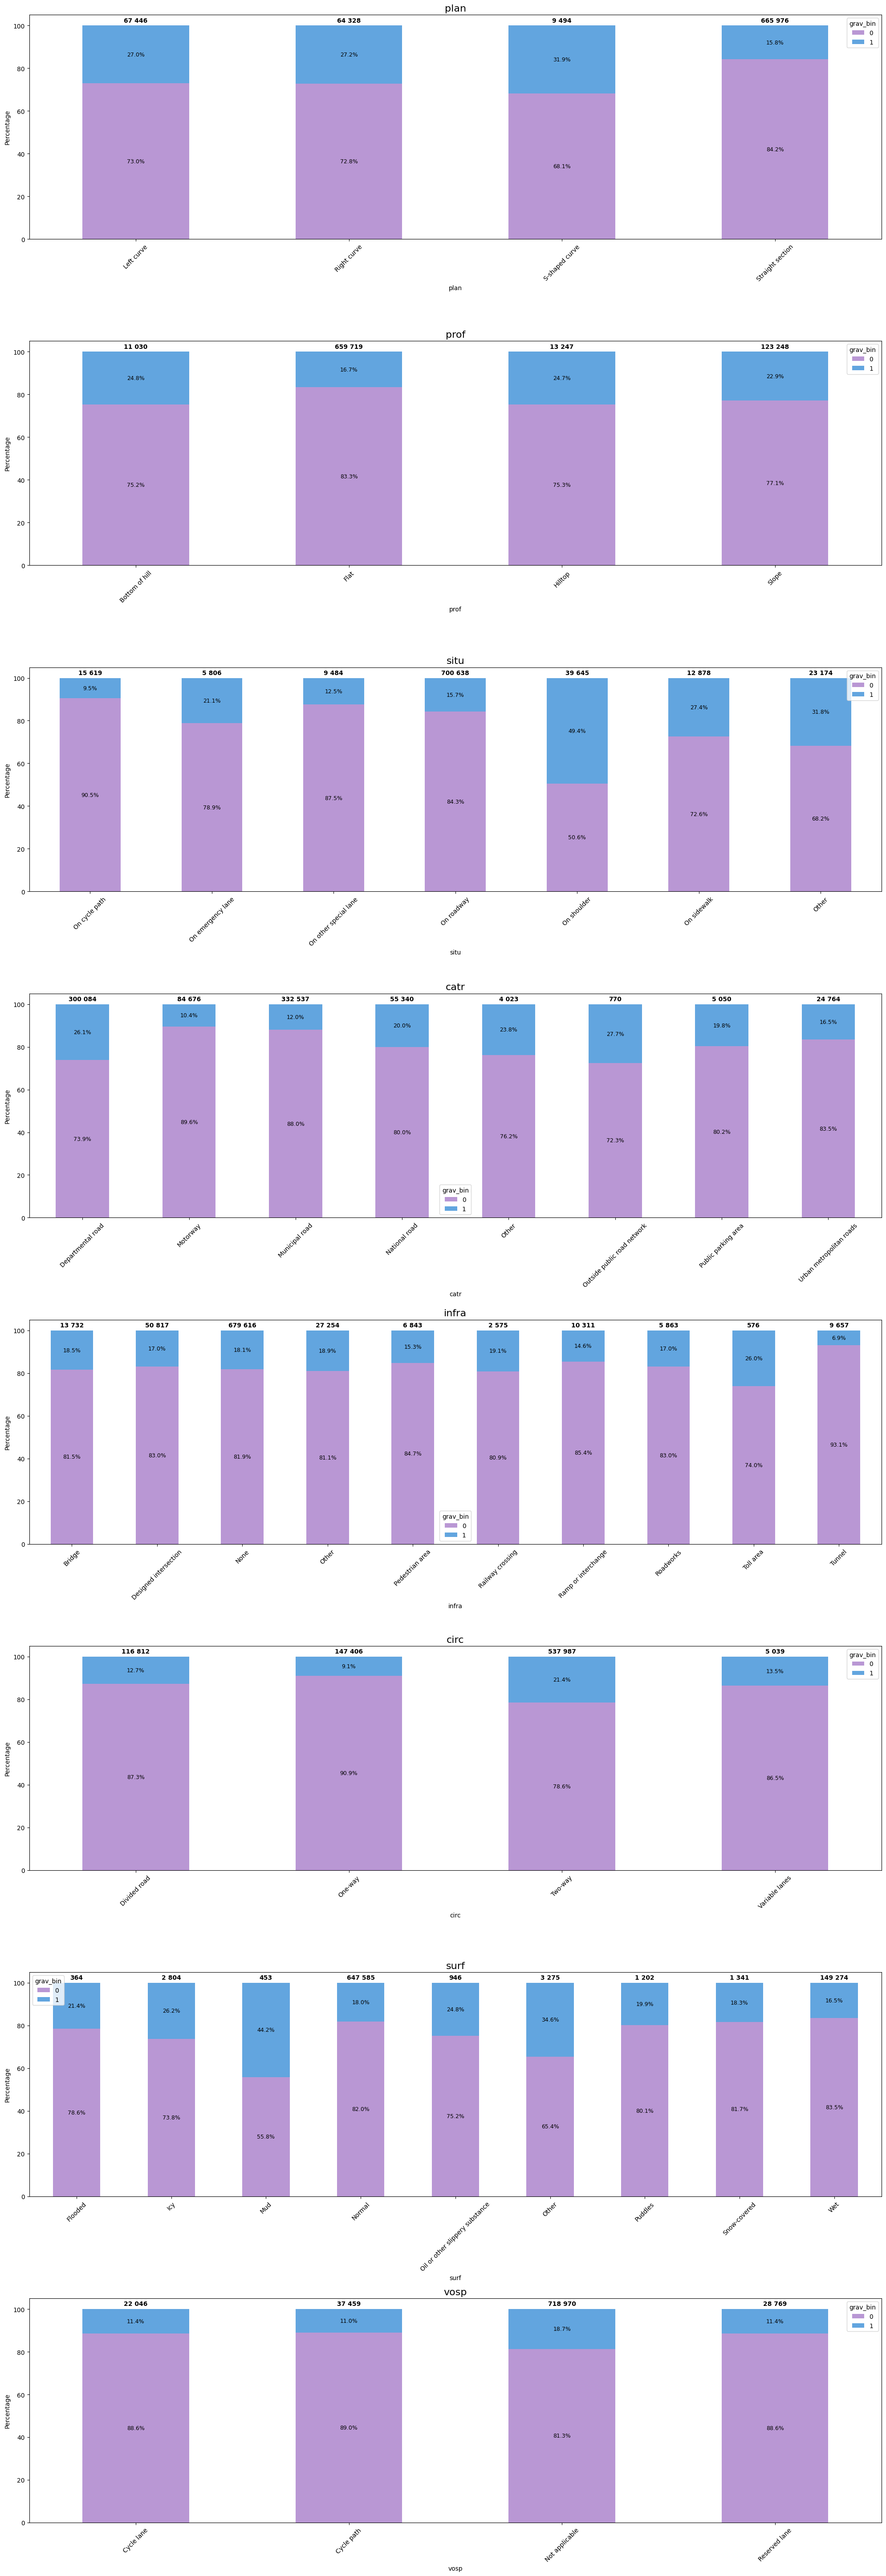

In [110]:
# plotting counts and proportions 
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_lieux_analyse = df_lieux_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_lieux_analyse[feature],
        df_lieux_analyse[target],
        normalize="index"
    ) * 100

    counts = df_lieux_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [111]:
def latex_escape_category(x):
    x = str(x)
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features:
    counts = df_lieux_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

print("\n".join(output_lines))

\texttt{catr} & Departmental road & 300 084 & 73.9 & 26.1 \\
 & Motorway & 84 676 & 89.6 & 10.4 \\
 & Municipal road & 332 537 & 88.0 & 12.0 \\
 & National road & 55 340 & 80.0 & 20.0 \\
 & Other & 4 023 & 76.2 & 23.8 \\
 & Outside public road network & 770 & 72.3 & 27.7 \\
 & Public parking area & 5 050 & 80.2 & 19.8 \\
 & Urban metropolitan roads & 24 764 & 83.5 & 16.5 \\
\hline
\texttt{circ} & Divided road & 116 812 & 87.3 & 12.7 \\
 & One-way & 147 406 & 90.9 & 9.1 \\
 & Two-way & 537 987 & 78.6 & 21.4 \\
 & Variable lanes & 5 039 & 86.5 & 13.5 \\
\hline
\texttt{nbv} & 1 & 80 938 & 86.8 & 13.2 \\
 & 2 & 523 619 & 78.5 & 21.5 \\
 & 3 & 66 429 & 89.7 & 10.3 \\
 & 4 & 95 255 & 88.9 & 11.1 \\
 & 5 & 12 422 & 88.1 & 11.9 \\
 & 6 & 20 547 & 93.1 & 6.9 \\
 & 7 & 2 015 & 92.8 & 7.2 \\
 & 8 & 6 019 & 95.8 & 4.2 \\
\hline
\texttt{vosp} & Cycle lane & 22 046 & 88.6 & 11.4 \\
 & Cycle path & 37 459 & 89.0 & 11.0 \\
 & Not applicable & 718 970 & 81.3 & 18.7 \\
 & Reserved lane & 28 769 & 88.6 &

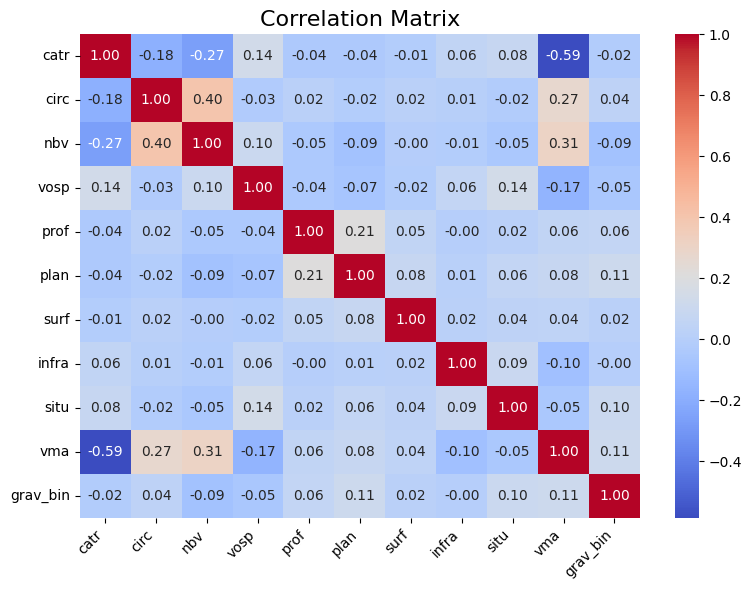

In [112]:
# let us also plot the correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    df_lieux_with_target[['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan',
       'surf', 'infra', 'situ', 'vma', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [113]:
# next let's see how well can we predict our target labels with these new features 
# first we are splitting our dataset
X = df_lieux_with_target[categorical_features + numerical_features]
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

In [114]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=20),
    "Decision Tree": DecisionTreeClassifier(random_state=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=20)
}

pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over_sampling", RandomOverSampler(random_state=20)),
        ("model", model)
    ])
for name, model in models.items():
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under_sampling", RandomUnderSampler(random_state=20)),
        ("model", model)
    ])

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (oversampling)"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Model selection with cross-validation (undersampling)"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20))
    print("\n", name)
    print(classification_report(y_train, y_pred))

Model selection with cross-validation (oversampling)

 Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    530388
           1       0.30      0.64      0.41    115407

    accuracy                           0.67    645795
   macro avg       0.60      0.66      0.59    645795
weighted avg       0.79      0.67      0.70    645795


 Decision Tree
              precision    recall  f1-score   support

           0       0.89      0.68      0.77    530388
           1       0.30      0.62      0.40    115407

    accuracy                           0.67    645795
   macro avg       0.59      0.65      0.59    645795
weighted avg       0.79      0.67      0.71    645795


 Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      0.71      0.79    530388
           1       0.31      0.60      0.41    115407

    accuracy                           0.69    645795
   macro avg     

              precision    recall  f1-score   support

           0       0.90      0.69      0.78    132597
           1       0.31      0.63      0.41     28852

    accuracy                           0.68    161449
   macro avg       0.60      0.66      0.60    161449
weighted avg       0.79      0.68      0.72    161449



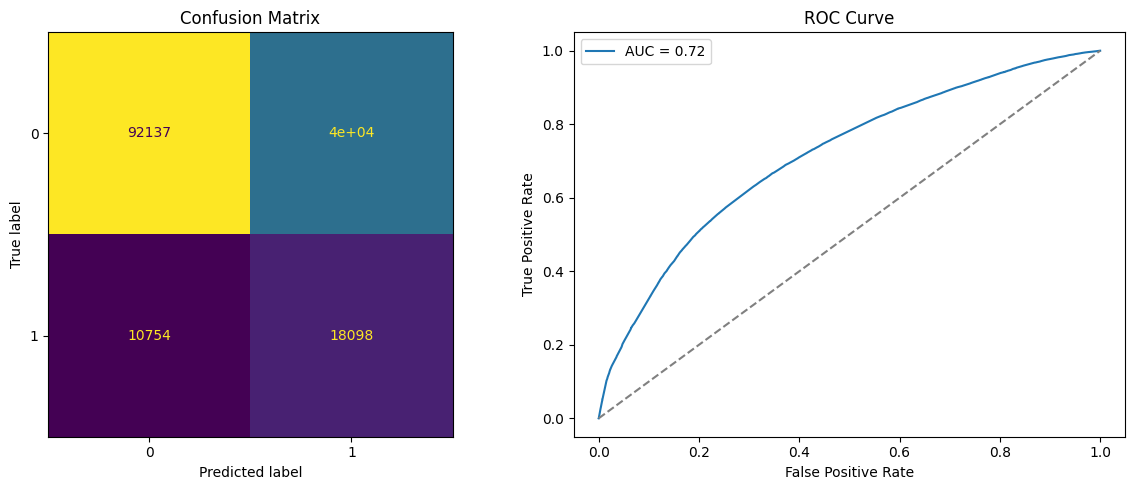

In [ ]:
# Here we selected Gradient Boosting with undersampling because it achieved the best 
# trade-off between recall and F1-score on the minority class during cross-validation.

# Train and predict
model = pipelines_under["Gradient Boosting"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

In [116]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)